In [141]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [142]:
df_train = pd.read_csv('train_landmark_features.csv')
df_test = pd.read_csv('test_landmark_features.csv')

In [143]:
# Menampilkan data yang memiliki missing values di df_train
missing_train = df_train[df_train.isnull().any(axis=1)]
print(missing_train)

# Menampilkan data yang memiliki missing values di df_test
missing_test = df_test[df_test.isnull().any(axis=1)]
print(missing_test)


Empty DataFrame
Columns: [D1, D2, D3, D4, D5, D6, D7, R1, R2, R3, R4, R5, R6, R7, R8, R9, R10, angle1, angle2, angle3, label]
Index: []

[0 rows x 21 columns]
Empty DataFrame
Columns: [D1, D2, D3, D4, D5, D6, D7, R1, R2, R3, R4, R5, R6, R7, R8, R9, R10, angle1, angle2, angle3, label]
Index: []

[0 rows x 21 columns]


In [144]:
# Menghapus baris dengan nilai NaN dari df_train
df_train_cleaned = df_train.dropna()

# Menghapus baris dengan nilai NaN dari df_test
df_test_cleaned = df_test.dropna()

# Menampilkan hasil setelah penghapusan
print("Dataset train setelah penghapusan missing values:")
print(df_train_cleaned)

print("Dataset test setelah penghapusan missing values:")
print(df_test_cleaned)


Dataset train setelah penghapusan missing values:
              D1          D2          D3         D4          D5         D6  \
0     120.933866  105.076163  155.929471  68.476273  102.956301  57.870545   
1     125.674182  107.004673  162.249807  60.108236  108.779594  63.387696   
2     128.003906  113.357840  167.191507  68.410526  109.000000  64.000000   
3     124.402572  107.056060  162.788206  65.192024  106.301458  60.074953   
4     117.004273   97.046381  162.111073  63.253458   99.020200  57.035077   
...          ...         ...         ...        ...         ...        ...   
2540  136.003676  115.017390  171.011696  72.006944  116.017240  64.070274   
2541  131.137333  117.000000  161.000000  69.634761  115.108644  67.067131   
2542  127.003937  110.222502  148.054044  61.057350  109.004587  62.008064   
2543  122.016392  100.179838  148.054044  63.631753  105.004762  59.008474   
2544  123.259888  101.044545  154.262763  63.285069  108.166538  60.074953   

             

In [145]:
df_train.head()

,D1,D2,D3,D4,D5,D6,D7,R1,R2,R3,...,R5,R6,R7,R8,R9,R10,angle1,angle2,angle3,label
0,120.933866,105.076163,155.929471,68.476273,102.956301,57.870545,30.413813,0.868873,0.775568,0.673870,...,0.562088,1.183266,0.478531,0.979825,0.665100,0.525549,68.032326,54.930170,74.374040,Heart
1,125.674182,107.004673,162.249807,60.108236,108.779594,63.387696,32.249031,0.851445,0.774572,0.659506,...,0.582717,0.948263,0.504381,1.016587,0.552569,0.508759,65.772255,48.853867,75.181925,Heart
2,128.003906,113.357840,167.191507,68.410526,109.000000,64.000000,34.000000,0.885581,0.765612,0.678012,...,0.587156,1.068914,0.499985,0.961557,0.627620,0.531250,63.628011,49.382405,74.058074,Heart
3,124.402572,107.056060,162.788206,65.192024,106.301458,60.074953,31.064449,0.860561,0.764199,0.657640,...,0.565138,1.085178,0.482908,0.992951,0.613275,0.517095,62.558041,51.888258,75.073994,Heart
4,117.004273,97.046381,162.111073,63.253458,99.020200,57.035077,30.016662,0.829426,0.721754,0.598641,...,0.575994,1.109027,0.487461,1.020339,0.638793,0.526284,61.313852,48.653230,73.321098,Heart


In [146]:
X_train = df_train_cleaned.iloc[:,:-1]
X_test = df_test_cleaned.iloc[:,:-1]
y_train = df_train_cleaned.iloc[:,-1]
y_test = df_test_cleaned.iloc[:,-1]

In [147]:
X_train.head()

,D1,D2,D3,D4,D5,D6,D7,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,angle1,angle2,angle3
0,120.933866,105.076163,155.929471,68.476273,102.956301,57.870545,30.413813,0.868873,0.775568,0.673870,1.174614,0.562088,1.183266,0.478531,0.979825,0.665100,0.525549,68.032326,54.930170,74.374040
1,125.674182,107.004673,162.249807,60.108236,108.779594,63.387696,32.249031,0.851445,0.774572,0.659506,1.155310,0.582717,0.948263,0.504381,1.016587,0.552569,0.508759,65.772255,48.853867,75.181925
2,128.003906,113.357840,167.191507,68.410526,109.000000,64.000000,34.000000,0.885581,0.765612,0.678012,1.174348,0.587156,1.068914,0.499985,0.961557,0.627620,0.531250,63.628011,49.382405,74.058074
3,124.402572,107.056060,162.788206,65.192024,106.301458,60.074953,31.064449,0.860561,0.764199,0.657640,1.170281,0.565138,1.085178,0.482908,0.992951,0.613275,0.517095,62.558041,51.888258,75.073994
4,117.004273,97.046381,162.111073,63.253458,99.020200,57.035077,30.016662,0.829426,0.721754,0.598641,1.181620,0.575994,1.109027,0.487461,1.020339,0.638793,0.526284,61.313852,48.653230,73.321098


In [148]:
X_test.head()

,D1,D2,D3,D4,D5,D6,D7,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10,angle1,angle2,angle3
0,123.328829,99.609237,166.364059,69.634761,104.388697,60.299254,32.249031,0.807672,0.741319,0.598743,1.181439,0.577642,1.154820,0.488931,1.047982,0.667072,0.534816,64.099386,51.149407,74.744881
1,128.062485,112.538882,165.245272,65.000000,109.004587,63.000000,33.000000,0.878781,0.774984,0.681041,1.174836,0.577957,1.031746,0.491947,0.968595,0.596305,0.523810,63.449177,50.007972,74.435886
2,123.146255,105.004762,153.160047,64.536811,101.079177,55.009090,30.016662,0.852683,0.804036,0.685588,1.218315,0.544218,1.173203,0.446697,0.962615,0.638478,0.545667,63.564945,52.018254,69.853273
3,120.066648,106.042444,165.003030,66.603303,101.019800,60.008333,32.000000,0.883197,0.727663,0.642670,1.188546,0.594025,1.109901,0.499792,0.952636,0.659309,0.533259,63.782192,48.999466,73.670074
4,130.003846,117.153745,170.105849,67.475922,110.018180,62.008064,33.015148,0.901156,0.764253,0.688711,1.181658,0.563617,1.088180,0.476971,0.939092,0.613316,0.532433,61.413584,48.390504,73.169732


In [149]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit scaler pada X_train dan transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test dengan scaler yang sudah di-fit dari X_train
X_test_scaled = scaler.transform(X_test)


In [150]:
X_train_scaled.shape

(2545, 20)

In [151]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Definisikan rentang parameter untuk SVM
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001],
}

# Inisialisasi model SVM
svc = SVC(probability=True)


# Set up GridSearchCV dengan cross-validation 5-fold
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit grid search pada data training
grid_search.fit(X_train_scaled, y_train)

# Menampilkan hasil terbaik
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Menggunakan model terbaik untuk prediksi pada data testing
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_scaled)

# Evaluasi akurasi model
from sklearn.metrics import accuracy_score
print("Test set accuracy: ", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best cross-validation score:  0.5324165029469549
Test set accuracy:  0.565149136577708


Confusion Matrix:
 [[83 15 16 10  7]
 [13 94  8  1  1]
 [46 19 38 18  6]
 [14  2 15 74 21]
 [13  7 15 30 71]]


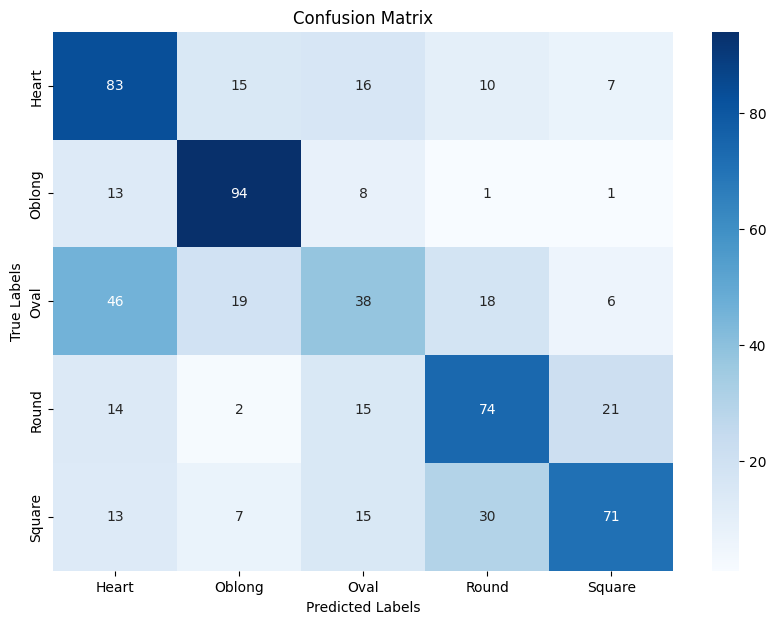

Classification Report:
               precision    recall  f1-score   support

       Heart       0.49      0.63      0.55       131
      Oblong       0.69      0.80      0.74       117
        Oval       0.41      0.30      0.35       127
       Round       0.56      0.59      0.57       126
      Square       0.67      0.52      0.59       136

    accuracy                           0.57       637
   macro avg       0.56      0.57      0.56       637
weighted avg       0.56      0.57      0.56       637



In [152]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svc.classes_, yticklabels=best_svc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Laporan klasifikasi
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit dan transform data training

# Simpan scaler ke file
joblib.dump(scaler, 'scaler.pkl')


In [ ]:
# Simpan model ke file
joblib.dump(best_svc, 'best_svc_model.pkl')

print("Model berhasil disimpan!")
